In [ ]:
!pip install ultralytics opencv-python-headless tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.3 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 14552311-hd_1920_1080_50fps.mp4 to 14552311-hd_1920_1080_50fps.mp4


In [ ]:
import os

# Voir tous les fichiers uploadés
print(os.listdir("/content"))

# Vérifier que ta vidéo est lisible
import cv2
cap = cv2.VideoCapture("14552311-hd_1920_1080_50fps.mp4")
print("Vidéo ouverte :", cap.isOpened())
print("Nombre de frames :", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("FPS :", cap.get(cv2.CAP_PROP_FPS))
cap.release()

['.config', '14552311-hd_1920_1080_50fps.mp4', 'sample_data']
Vidéo ouverte : True
Nombre de frames : 600
FPS : 50.0


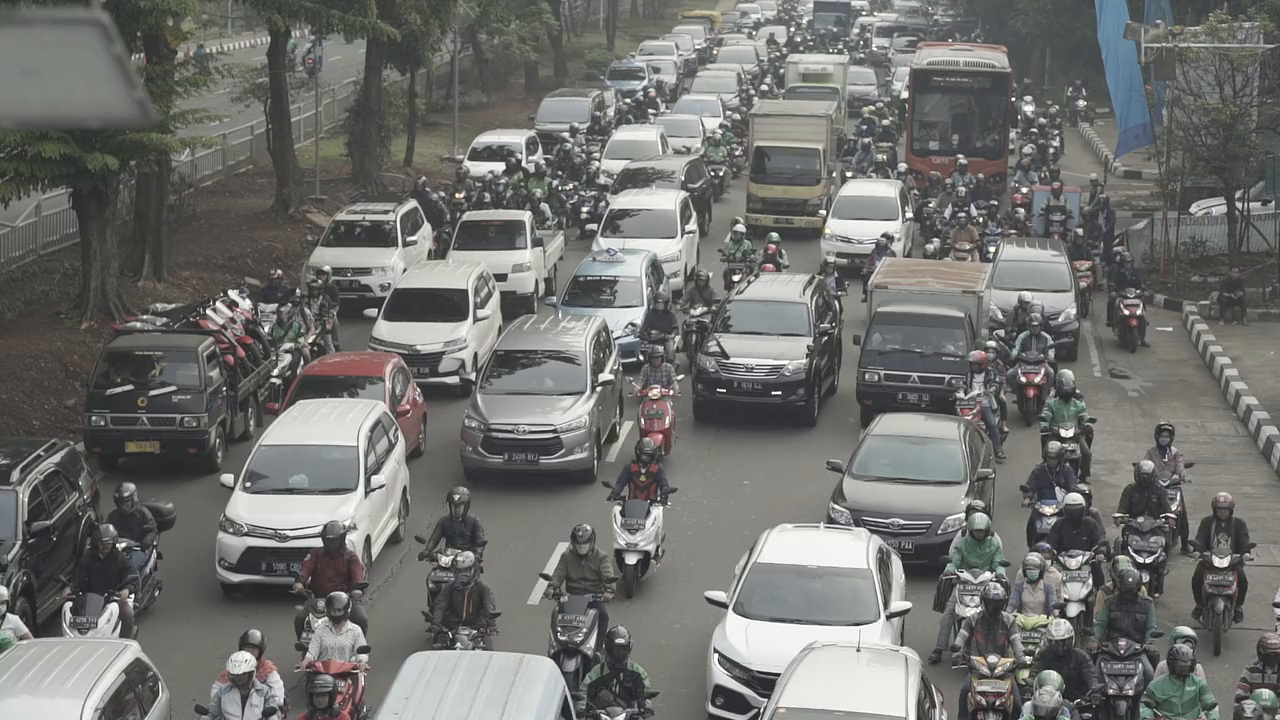

Taille de la frame : (720, 1280, 3)


In [ ]:
import cv2
from IPython.display import display
from PIL import Image
import numpy as np

cap = cv2.VideoCapture("14552311-hd_1920_1080_50fps.mp4")
ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(frame_rgb))
    print("Taille de la frame :", frame.shape)
else:
    print("Erreur : impossible de lire la vidéo")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


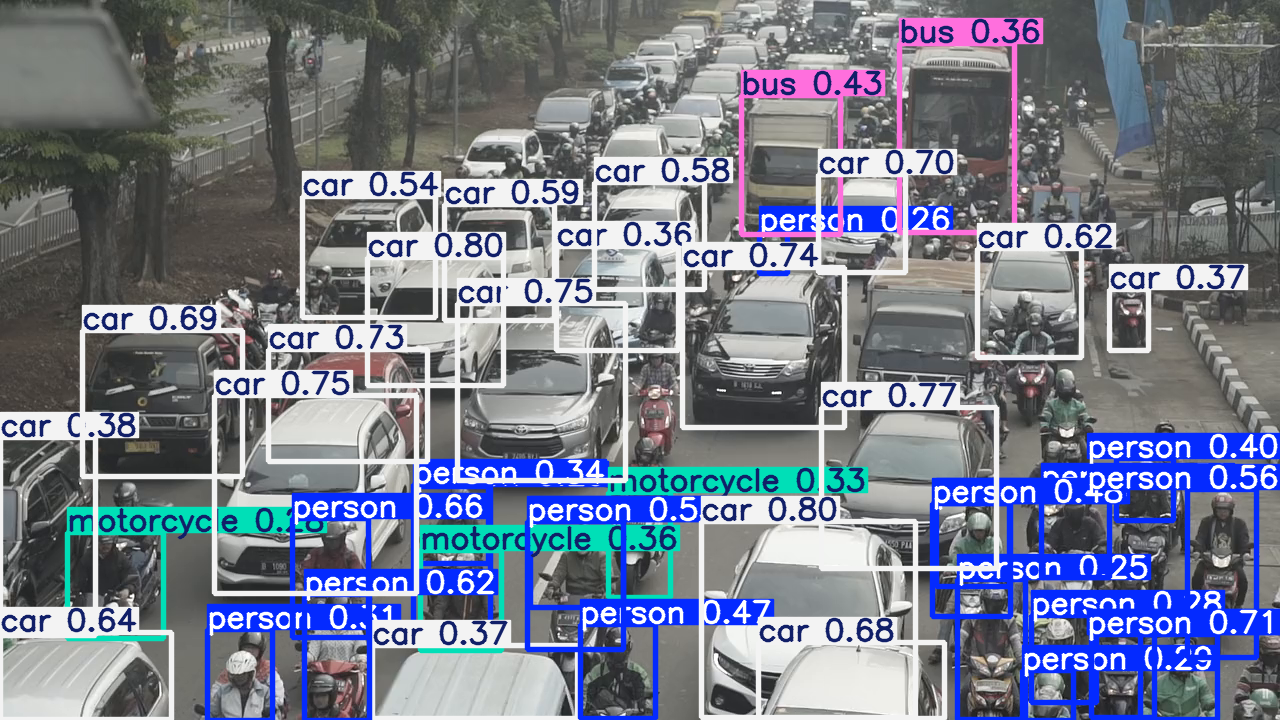

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # se télécharge automatiquement

# Tester sur la première frame
results = model(frame, verbose=False)[0]

# Afficher le résultat
frame_annote = results.plot()
frame_rgb = cv2.cvtColor(frame_annote, cv2.COLOR_BGR2RGB)
display(Image.fromarray(frame_rgb))

 Extraire les images par catégorie

In [ ]:
import os, cv2
from ultralytics import YOLO

VIDEO = "/content/14552311-hd_1920_1080_50fps.mp4"
model = YOLO("yolov8n.pt")
cap   = cv2.VideoCapture(VIDEO)

os.makedirs("dataset/camion", exist_ok=True)
compteur = 0
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frame_idx += 1
    if frame_idx % 2 != 0:
        continue

    results = model(frame, verbose=False)[0]
    for box in results.boxes:
        cls_id = int(box.cls[0])
        conf   = float(box.conf[0])
        if cls_id == 7 and conf > 0.25:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            crop = frame[y1:y2, x1:x2]
            if crop.shape[0] < 20 or crop.shape[1] < 20:
                continue
            crop = cv2.resize(crop, (64, 64))
            cv2.imwrite(f"dataset/camion/camion_{compteur:04d}.jpg", crop)
            compteur += 1

cap.release()
print("Extraction terminée !")
for genre, n in compteurs.items():
    print(f"  {genre}: {n} images")

Camions extraits : 291


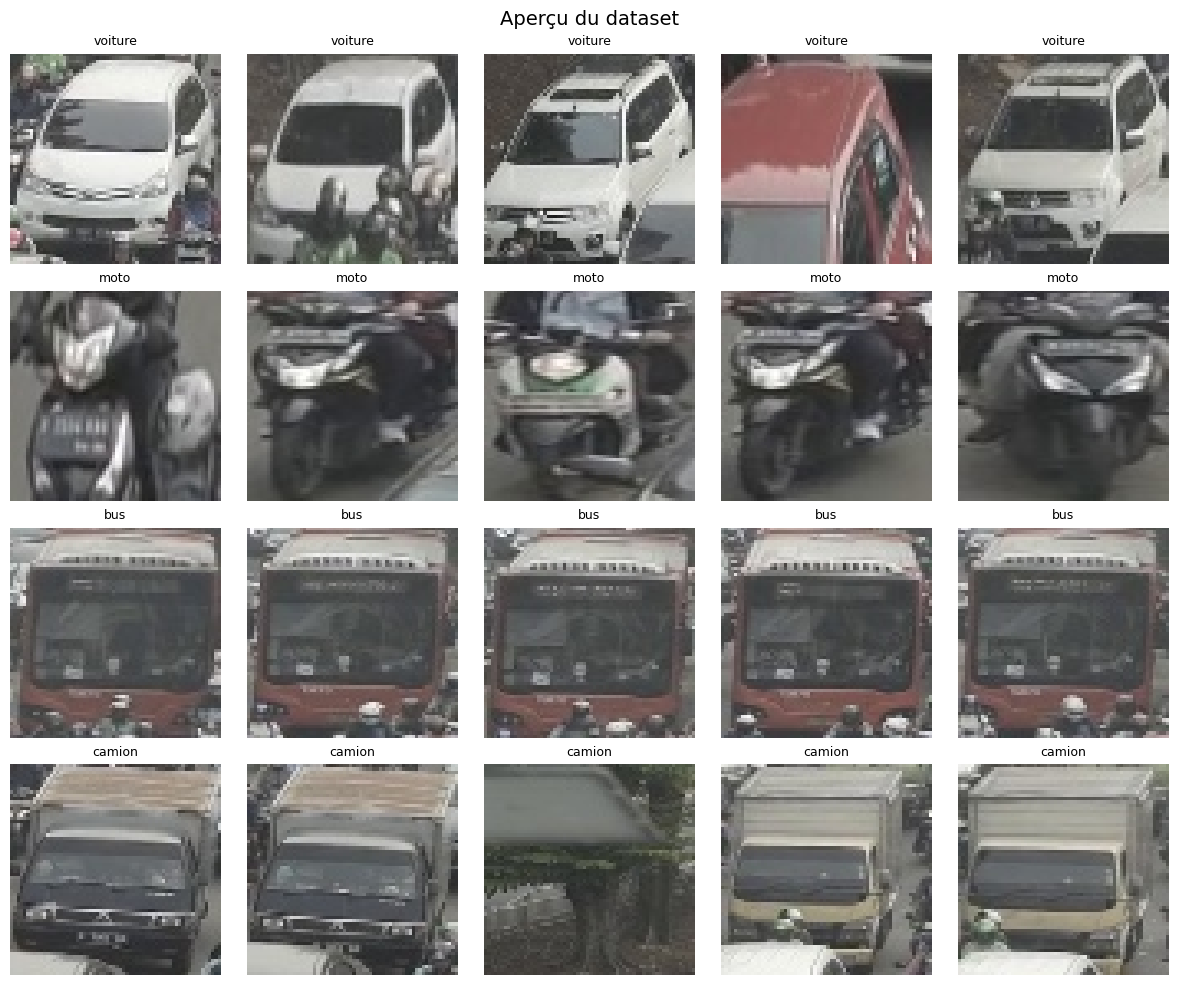

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
fig.suptitle("Aperçu du dataset", fontsize=14)

for i, genre in enumerate(["voiture", "moto", "bus", "camion"]):
    dossier = f"dataset/{genre}"
    fichiers = os.listdir(dossier)[:5]
    for j, fichier in enumerate(fichiers):
        img = Image.open(f"{dossier}/{fichier}")
        axes[i][j].imshow(img)
        axes[i][j].set_title(genre, fontsize=9)
        axes[i][j].axis("off")

plt.tight_layout()
plt.savefig("apercu_dataset.png")
plt.show()